# Notebook 08 — Federated Learning with Flower (No DP)

## What this notebook does
I implement and run federated learning using the Flower (flwr) framework across the 5 simulated Nigerian hospital sites — WITHOUT differential privacy. This gives me a clean FL baseline before adding DP noise in Notebook 09.

## Why this step matters
Separating FL-without-DP from FL-with-DP lets me isolate two distinct costs:
1. The **federation cost**: performance loss due to distributed training
2. The **privacy cost**: additional performance loss from DP noise

## What Python / ML concepts I practise
- Flower client/server simulation API (`fl.simulation.start_simulation`)
- FedAvg aggregation strategy
- Per-round metric logging
- Comparing federated vs centralised training curves

## Input files expected
- `data/processed/train.csv`, `val.csv`, `test.csv`
- `data/processed/site_{i}_train.csv` for i in 0..4

## Output files created
- `models/federated/global_model_no_dp.pth`
- `models/federated/fl_history_no_dp.csv`
- `reports/figures/fl_training_curves_no_dp.png`

## How this connects to the main project question
This is the first test of the federated approach. The gap between this and the centralised baseline is the pure federation cost, before privacy is added.

In [2]:
import sys
from pathlib import Path
project_root = Path.cwd().parent
sys.path.insert(0, str(project_root))


USE_MOCK_DATA = True

import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
from torch.utils.data import DataLoader
from collections import OrderedDict
from sklearn.metrics import roc_auc_score

from src.config import load_config
from src.paths import get_paths
from src.data_utils import TBDataset, build_transforms, get_class_weights
from src.model import build_model, count_parameters
from src.fl_client import TBClient, train_one_epoch, evaluate_model
from src.fl_server import build_fedavg_strategy, weighted_average_metrics
from src.metrics import compute_metrics
from src.visualization import set_publication_style, save_figure, plot_fl_training_curves

cfg   = load_config()
paths = get_paths()
set_publication_style()

SEED     = cfg["project"]["random_seed"]
torch.manual_seed(SEED)
np.random.seed(SEED)

DEVICE    = torch.device("cuda" if torch.cuda.is_available() else "cpu")
N_SITES   = cfg["federated"]["num_clients"]
N_ROUNDS  = cfg["federated"]["num_rounds"] if not USE_MOCK_DATA else 5
SITE_NAMES = cfg["federated"]["site_names"]
IMAGE_SIZE = cfg["data"]["image_size"]
BATCH_SIZE = cfg["training"]["batch_size"]

# Use fewer rounds in mock mode for speed
print(f"Device: {DEVICE}")
print(f"FL Rounds: {N_ROUNDS} ({'mock' if USE_MOCK_DATA else 'full'})")
print(f"Sites: {N_SITES}")

Device: cpu
FL Rounds: 5 (mock)
Sites: 5


## How Flower Simulation Works

Instead of spawning real network connections, Flower's `start_simulation` runs FL
entirely in a single Python process — clients are called sequentially (or in parallel
with Ray). This makes it easy to reproduce on a laptop without networking infrastructure.

```
fl.simulation.start_simulation(
    client_fn   = client_fn,    # function that builds a client given client_id
    num_clients = N_SITES,
    config      = ServerConfig(num_rounds=N_ROUNDS),
    strategy    = strategy,     # FedAvg
)
```

Each round:
1. Strategy selects clients
2. `client.fit()` is called → local training → updated weights returned
3. FedAvg aggregates weights
4. `client.evaluate()` is called → val metrics returned
5. Server-side `evaluate_fn` runs on global test set


In [3]:
# ── Load all site DataLoaders ──────────────────────────────────────

train_transform = build_transforms(image_size=IMAGE_SIZE, split="train",
    normalize_mean=cfg["augmentation"]["normalize_mean"],
    normalize_std=cfg["augmentation"]["normalize_std"])
val_transform = build_transforms(image_size=IMAGE_SIZE, split="val",
    normalize_mean=cfg["augmentation"]["normalize_mean"],
    normalize_std=cfg["augmentation"]["normalize_std"])

# Global val and test sets (same for all clients and server evaluation)
val_df   = pd.read_csv(paths["processed"] / "val.csv")
test_df  = pd.read_csv(paths["processed"] / "test.csv")
val_dataset  = TBDataset(val_df,  transform=val_transform)
test_dataset = TBDataset(test_df, transform=val_transform)
val_loader  = DataLoader(val_dataset,  batch_size=BATCH_SIZE, shuffle=False, num_workers=0)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=0)

# Per-site training loaders
site_loaders = {}
for i in range(N_SITES):
    site_df = pd.read_csv(paths["processed"] / f"site_{i}_train.csv")
    ds = TBDataset(site_df, transform=train_transform)
    site_loaders[i] = DataLoader(ds, batch_size=BATCH_SIZE, shuffle=True, num_workers=0)

print(f"Loaded {N_SITES} site training loaders:")
for i, loader in site_loaders.items():
    print(f"  Site {i} ({SITE_NAMES[i][:30]}...): {len(loader.dataset)} images")
print(f"Val: {len(val_dataset)} | Test: {len(test_dataset)}")

Loaded 5 site training loaders:
  Site 0 (Lagos_University_Teaching_Hosp...): 277 images
  Site 1 (Aminu_Kano_Teaching_Hospital...): 82 images
  Site 2 (University_of_Nigeria_Teaching...): 60 images
  Site 3 (Obafemi_Awolowo_University_Tea...): 88 images
  Site 4 (University_College_Hospital_Ib...): 53 images
Val: 120 | Test: 120


## Define the Flower Client Factory

Flower's `start_simulation` requires a function `client_fn(cid: str) -> fl.client.Client`.
This factory creates a fresh model + optimizer for each client on each round call.

In [4]:
import flwr as fl
from flwr.server import ServerConfig

# Global tracking list — we append metrics here from the evaluate_fn closure
fl_round_metrics = []

def client_fn(cid: str) -> TBClient:
    """
    Factory function: given a client ID string, build and return a TBClient.

    Flower calls this each round to get a client. We build a fresh model
    and load the site-specific DataLoader.

    Parameters
    ----------
    cid : str
        Client ID, e.g. '0', '1', '2', ...
    """
    client_id = int(cid)
    site_name = SITE_NAMES[client_id]

    # Build a fresh model for this client
    model = build_model(
        pretrained=True,
        num_classes=cfg["model"]["num_classes"],
        dropout=cfg["model"]["dropout"],
    ).to(DEVICE)

    client = TBClient(
        model        = model,
        train_loader = site_loaders[client_id],
        val_loader   = val_loader,    # All clients evaluate on the same val set
        device       = DEVICE,
        config       = cfg,
        client_id    = site_name,
    )
    return client

print("Client factory defined.")
print("Each call to client_fn() creates a fresh ResNet-18 + TBClient for one site.")

Client factory defined.
Each call to client_fn() creates a fresh ResNet-18 + TBClient for one site.


In [5]:
# ── Build server-side evaluation model ─────────────────────────────
# A separate model instance used ONLY by the server to evaluate the
# aggregated global weights on the test set after each round.

eval_model = build_model(
    pretrained=False,   # Weights loaded from aggregated parameters
    num_classes=cfg["model"]["num_classes"],
    dropout=cfg["model"]["dropout"],
).to(DEVICE)

from src.fl_server import get_eval_fn

# We store per-round results in a list via closure
round_results = []

def evaluate_fn_with_logging(server_round, parameters, config):
    """Server-side evaluation with round result logging."""
    from collections import OrderedDict
    params_dict = zip(eval_model.state_dict().keys(), parameters)
    state_dict  = OrderedDict({k: torch.tensor(v) for k, v in params_dict})
    eval_model.load_state_dict(state_dict, strict=True)
    eval_model.eval()

    criterion = nn.CrossEntropyLoss()
    all_probs, all_labels = [], []
    total_loss = 0.0

    with torch.no_grad():
        for images, labels, _ in test_loader:
            images = images.to(DEVICE)
            labels = labels.to(DEVICE)
            logits = eval_model(images)
            loss   = criterion(logits, labels)
            probs  = torch.softmax(logits, dim=1)[:, 1]
            total_loss += loss.item() * images.size(0)
            all_probs.extend(probs.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())

    n         = len(all_labels)
    test_loss = total_loss / n if n > 0 else 0.0
    y_true    = np.array(all_labels)
    y_prob    = np.array(all_probs)

    auc = 0.0
    if len(np.unique(y_true)) == 2:
        auc = float(roc_auc_score(y_true, y_prob))

    round_results.append({"round": server_round, "test_loss": test_loss, "test_auc": auc})
    print(f"  [Round {server_round:3d}] Test Loss: {test_loss:.4f} | Test AUC: {auc:.4f}")
    return test_loss, {"test_auc": auc}

# Build FedAvg strategy
from flwr.server.strategy import FedAvg
strategy = FedAvg(
    fraction_fit          = cfg["federated"]["fraction_fit"],
    fraction_evaluate     = cfg["federated"]["fraction_fit"],
    min_fit_clients       = min(cfg["federated"]["min_fit_clients"], N_SITES),
    min_evaluate_clients  = min(cfg["federated"]["min_evaluate_clients"], N_SITES),
    min_available_clients = min(cfg["federated"]["min_available_clients"], N_SITES),
    evaluate_fn           = evaluate_fn_with_logging,
    fit_metrics_aggregation_fn     = weighted_average_metrics,
    evaluate_metrics_aggregation_fn= weighted_average_metrics,
)
print("FedAvg strategy built.")

FedAvg strategy built.


In [6]:
import ray
import flwr as fl
from flwr.server import ServerConfig

# No runtime_env needed once src is properly installed
if ray.is_initialized():
    ray.shutdown()

print(f"Starting FL simulation: {N_ROUNDS} rounds, {N_SITES} sites...")
print("This may take several minutes on CPU with real data.")
print()

history = fl.simulation.start_simulation(
    client_fn   = client_fn,
    num_clients = N_SITES,
    config      = ServerConfig(num_rounds=N_ROUNDS),
    strategy    = strategy,
)

print()
print("FL simulation complete!")

Starting FL simulation: 5 rounds, 5 sites...
This may take several minutes on CPU with real data.



	Instead, use the `flwr run` CLI command to start a local simulation in your Flower app, as shown for example below:

		$ flwr new  # Create a new Flower app from a template

		$ flwr run  # Run the Flower app in Simulation Mode

	Using `start_simulation()` is deprecated.

            This is a deprecated feature. It will be removed
            entirely in future versions of Flower.
        
INFO :      Starting Flower simulation, config: num_rounds=5, no round_timeout
2026-06-15 06:34:35,253	INFO worker.py:2012 -- Started a local Ray instance.
c:\Users\Peter\.ml\Lib\site-packages\ray\_private\worker.py:2051: FutureWarning: Tip: In future versions of Ray, Ray will no longer override accelerator visible devices env var if num_gpus=0 or num_gpus=None (default). To enable this behavior and turn off this error message, set RAY_ACCEL_ENV_VAR_OVERRIDE_ON_ZERO=0
  warnings.warn(
INFO :      Flower VCE: Ray initialized with resources: {'object_store_memory': 2229431500.0, 'node:127.0.0.1': 1.0

  [Round   0] Test Loss: 0.7766 | Test AUC: 0.4173


(ClientAppActor pid=32948) WARNING :   DEPRECATED FEATURE: `client_fn` now expects a signature `def client_fn(context: Context)`.The provided `client_fn` has signature: {'cid': <Parameter "cid: str">}. You can import the `Context` like this: `from flwr.app import Context`
(ClientAppActor pid=32948) 
(ClientAppActor pid=32948)             This is a deprecated feature. It will be removed
(ClientAppActor pid=32948)             entirely in future versions of Flower.
(ClientAppActor pid=32948)         
(ClientAppActor pid=32948) WARNING :   Deprecation Warning: The `client_fn` function must return an instance of `Client`, but an instance of `NumpyClient` was returned. Please use `NumPyClient.to_client()` method to convert it to `Client`.
(ClientAppActor pid=28628) WARNING :   DEPRECATED FEATURE: `client_fn` now expects a signature `def client_fn(context: Context)`.The provided `client_fn` has signature: {'cid': <Parameter "cid: str">}. You can import the `Context` like this: `from flwr.app 

  [Round   1] Test Loss: 0.5527 | Test AUC: 0.8527


...

  [Round   4] Test Loss: 0.4419 | Test AUC: 0.9069


(ClientAppActor pid=32948) 
(ClientAppActor pid=32948)         
(ClientAppActor pid=32948) WARNING :   DEPRECATED FEATURE: `client_fn` now expects a signature `def client_fn(context: Context)`.The provided `client_fn` has signature: {'cid': <Parameter "cid: str">}. You can import the `Context` like this: `from flwr.app import Context` [repeated 5x across cluster]
(ClientAppActor pid=32948)             This is a deprecated feature. It will be removed [repeated 5x across cluster]
(ClientAppActor pid=32948)             entirely in future versions of Flower. [repeated 5x across cluster]
(ClientAppActor pid=16392) WARNING :   Deprecation Warning: The `client_fn` function must return an instance of `Client`, but an instance of `NumpyClient` was returned. Please use `NumPyClient.to_client()` method to convert it to `Client`. [repeated 5x across cluster]
(ClientAppActor pid=28628) 
(ClientAppActor pid=28628)         
(ClientAppActor pid=11080) 
(ClientAppActor pid=11080)         
(ClientAppAct

  [Round   5] Test Loss: 0.5377 | Test AUC: 0.9086


(ClientAppActor pid=11080) 
(ClientAppActor pid=11080)         
(ClientAppActor pid=11080) WARNING :   DEPRECATED FEATURE: `client_fn` now expects a signature `def client_fn(context: Context)`.The provided `client_fn` has signature: {'cid': <Parameter "cid: str">}. You can import the `Context` like this: `from flwr.app import Context` [repeated 5x across cluster]
(ClientAppActor pid=11080)             This is a deprecated feature. It will be removed [repeated 5x across cluster]
(ClientAppActor pid=11080)             entirely in future versions of Flower. [repeated 5x across cluster]
(ClientAppActor pid=28628) WARNING :   Deprecation Warning: The `client_fn` function must return an instance of `Client`, but an instance of `NumpyClient` was returned. Please use `NumPyClient.to_client()` method to convert it to `Client`. [repeated 5x across cluster]
(ClientAppActor pid=31756) 
(ClientAppActor pid=31756)         
(ClientAppActor pid=28628) 
(ClientAppActor pid=28628)         
(ClientAppAct


FL simulation complete!


FL history saved.
   round  test_loss  test_auc
1      1   0.552733  0.852737
2      2   0.469156  0.906919
3      3   0.499992  0.893026
4      4   0.441890  0.906919
5      5   0.537721  0.908586


c:\Users\Peter\.ml\Lib\site-packages\IPython\core\pylabtools.py:77: DeprecationWarning: backend2gui is deprecated since IPython 8.24, backends are managed in matplotlib and can be externally registered.
  warnings.warn(


Figure saved: 'fl_training_curves_no_dp.png' and 'fl_training_curves_no_dp.pdf'


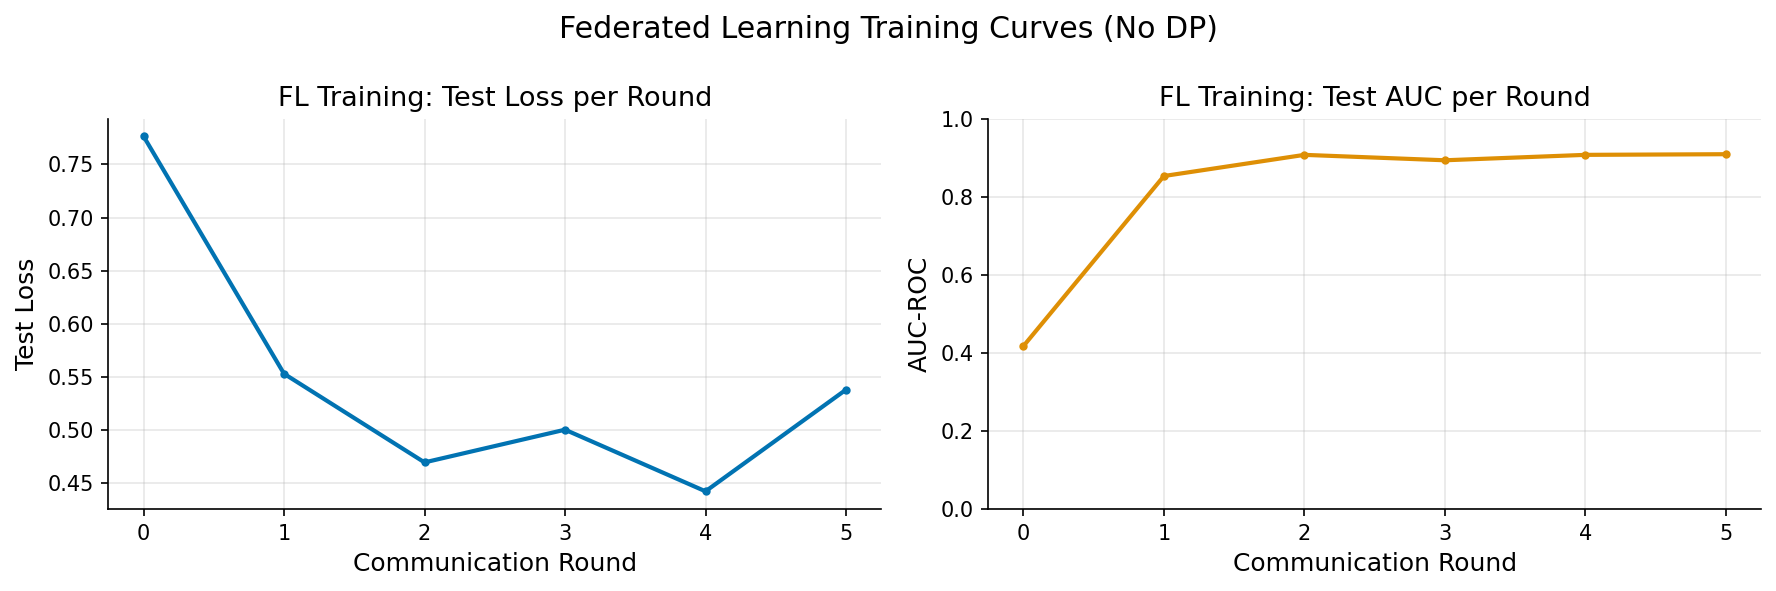

In [7]:
# ── Save training history ───────────────────────────────────────────
fed_model_dir = paths["federated_model_dir"]
fed_model_dir.mkdir(parents=True, exist_ok=True)

history_df = pd.DataFrame(round_results)
history_df.to_csv(fed_model_dir / "fl_history_no_dp.csv", index=False)
print("FL history saved.")
print(history_df.tail())

# ── Plot training curves ──────────────────────────────────────────────
if len(history_df) > 0:
    fig, axes = plt.subplots(1, 2, figsize=(12, 4))

    axes[0].plot(history_df["round"], history_df["test_loss"], "o-",
                 color=plt.rcParams["axes.prop_cycle"].by_key()["color"][0], lw=2, ms=3)
    axes[0].set_xlabel("Communication Round")
    axes[0].set_ylabel("Test Loss")
    axes[0].set_title("FL Training: Test Loss per Round")
    axes[0].grid(alpha=0.3)

    axes[1].plot(history_df["round"], history_df["test_auc"], "o-",
                 color=plt.rcParams["axes.prop_cycle"].by_key()["color"][1], lw=2, ms=3)
    axes[1].set_xlabel("Communication Round")
    axes[1].set_ylabel("AUC-ROC")
    axes[1].set_title("FL Training: Test AUC per Round")
    axes[1].set_ylim(0, 1)
    axes[1].grid(alpha=0.3)

    plt.suptitle("Federated Learning Training Curves (No DP)")
    plt.tight_layout()
    save_figure(fig, "fl_training_curves_no_dp", paths["figures"], paths["paper_figures"])
    plt.show()

In [8]:
# ── Save final global model weights ─────────────────────────────────
# Extract final aggregated weights from the Flower history object
# and save them as a standard PyTorch state dict.

final_params = history.parameters_aggregated[-1] if hasattr(history, 'parameters_aggregated') and history.parameters_aggregated else None

if final_params is not None:
    params_dict = zip(eval_model.state_dict().keys(),
                      [torch.tensor(p) for p in final_params])
    state_dict  = OrderedDict(params_dict)
    eval_model.load_state_dict(state_dict, strict=True)
    torch.save(eval_model.state_dict(), fed_model_dir / "global_model_no_dp.pth")
    print(f"Final global model saved: {fed_model_dir / 'global_model_no_dp.pth'}")
else:
    # Fallback: save current eval_model state
    torch.save(eval_model.state_dict(), fed_model_dir / "global_model_no_dp.pth")
    print("Final global model saved (from eval_model state).")

# Quick final evaluation
eval_model.eval()
all_probs, all_labels = [], []
with torch.no_grad():
    for images, labels, _ in test_loader:
        logits = eval_model(images.to(DEVICE))
        probs  = torch.softmax(logits, dim=1)[:, 1]
        all_probs.extend(probs.cpu().numpy())
        all_labels.extend(labels.numpy())

np.save(fed_model_dir / "test_y_true.npy", np.array(all_labels))
np.save(fed_model_dir / "test_y_prob_no_dp.npy", np.array(all_probs))

metrics = compute_metrics(np.array(all_labels), np.array(all_probs))
print()
print("Federated (No DP) — Final Test Results:")
for k, v in metrics.items():
    if isinstance(v, float):
        print(f"  {k:25s}: {v:.4f}")

Final global model saved (from eval_model state).

Federated (No DP) — Final Test Results:
  auc_roc                  : 0.9086
  auc_prc                  : 0.9164
  threshold                : 0.1783
  sensitivity              : 0.7627
  specificity              : 0.9180
  ppv                      : 0.9000
  npv                      : 0.8000
  f1                       : 0.8257
  accuracy                 : 0.8417
  balanced_accuracy        : 0.8404
